# Data understanding and preprocessing

This notebook examines every recorded stream used in the assignment: **accelerometer, gyroscope and gravity**. It first checks one recording in detail, then repeats the same structural checks and exploratory analysis across all 41 recordings.

The validated export preserves every recorded sample. Nothing is cropped, filtered, clipped, resampled or scaled. This keeps the preparation reproducible and avoids inventing activity boundaries that are not present in the annotation files.

## 1. Setup

The next cells import the libraries, set the visual style, and define the source and output folders.

In [1]:
from pathlib import Path

import sys
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
def find_project_root(start_path):
    # look upwards until the raw data folder is found
    start_path = Path(start_path).resolve()
    search_paths = (start_path, *start_path.parents)

    for path in search_paths:
        # also check if the notebook is inside the Assignment 1 folder
        for candidate in (path, path / "Assignment 1"):
            if (candidate / "data" / "recordings" / "raw").is_dir():
                return candidate

    raise FileNotFoundError(
        "Could not find data/recordings/raw. Run this notebook from the "
        "repository root or one of its subdirectories."
    )


# define paths and the three sensor streams used in this analysis
PROJECT_ROOT = find_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data" / "recordings" / "raw"
SENSORS = ("Accelerometer", "Gyroscope", "Gravity")
AXES = ["x", "y", "z"]
UNITS = {"Accelerometer": "m/s²", "Gyroscope": "rad/s", "Gravity": "m/s²"}

# select one example recording from each class
BUMPY_EXAMPLE_DIR = DATA_ROOT / "bumpy/lars/cb_2_bumpy_lars"
SMOOTH_EXAMPLE_DIR = DATA_ROOT / "smooth/lars/SSC-smooth-test1-lars"

# use consistent settings for the plots
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# print the package versions for reproducibility
print("Python:", sys.version.split()[0])
print(
    "NumPy:", np.__version__,
    "pandas:", pd.__version__,
    "Matplotlib:", matplotlib.__version__,
)


Python: 3.12.14
NumPy: 2.5.2 pandas: 3.0.5 Matplotlib: 3.11.1


## 2. Understand one complete recording

One bumpy recording is inspected before the whole dataset. Its accelerometer, gyroscope, and gravity streams are compared by structure, units, scale, and timing. This follows the practical's sequence of inspecting data before changing it.

In [3]:
# load every required sensor from the same example recording
example_streams = {
    sensor: pd.read_csv(BUMPY_EXAMPLE_DIR / f"{sensor}.csv", float_precision="round_trip")
    for sensor in SENSORS
}

# keep the preview short while showing each sensor's raw structure
example_preview = pd.concat(
    {sensor: data.head(3) for sensor, data in example_streams.items()},
    names=["sensor", "source_row"],
)
display(example_preview)

example_dtypes = pd.DataFrame(
    {sensor: data.dtypes.astype(str) for sensor, data in example_streams.items()}
).T
example_dtypes.index.name = "sensor"
display(example_dtypes)

# compare axis summaries by sensor so different units remain separate
example_descriptives = pd.concat(
    {
        sensor: data[AXES].describe().loc[["mean", "std", "min", "max"]]
        for sensor, data in example_streams.items()
    },
    names=["sensor", "statistic"],
).round(4)
display(example_descriptives)


time  seconds_elapsed         z  \
sensor        source_row                                                   
Accelerometer 0           1788862107461369600         0.045370 -0.713455   
              1           1788862107471376400         0.055376 -0.676802   
              2           1788862107481384400         0.065385 -0.487768   
Gyroscope     0           1788862107461369600         0.045370  0.189336   
              1           1788862107471376400         0.055376  0.377980   
              2           1788862107481384400         0.065385  0.555704   
Gravity       0           1788862107461369600         0.045370  9.637243   
              1           1788862107471376400         0.055376  9.639047   
              2           1788862107481384400         0.065385  9.641848   

                                 y         x  
sensor        source_row                      
Accelerometer 0          -0.347207 -0.227989  
              1          -0.322843 -0.221322  
              2          -0.293544  0.057028  
Gyroscope     0          -0.405765  0.022289  
              1          -0.500684 -0.026957  
              2          -0.596804 -0.082470  
Gravity       0           1.767118 -0.413807  
              1           1.768043 -0.364958  
              2           1.764332 -0.303781

,time,seconds_elapsed,z,y,x
sensor,,,,,
Accelerometer,int64,float64,float64,float64,float64
Gyroscope,int64,float64,float64,float64,float64
Gravity,int64,float64,float64,float64,float64


x        y        z
sensor        statistic                           
Accelerometer mean        0.0303  -0.4413   0.2667
              std         1.7964   2.3285   2.3756
              min       -11.7438 -19.1971 -22.1025
              max        13.1171  13.2609  15.5439
Gyroscope     mean        0.0414  -0.0283  -0.0311
              std         1.3332   0.9688   0.8745
              min        -2.5963  -9.3710  -9.1959
              max         4.6420  11.2802   4.9811
Gravity       mean        1.8087  -5.2650  -5.9754
              std         1.1461   3.1396   4.2790
              min        -0.6547  -9.1178  -9.5723
              max         9.0577   4.7458   9.7042

### What the data represents

Each row contains one sensor measurement. The folder labels (`smooth` or `bumpy`) refer to the road recorded during the ride, so they do not necessarily describe every moment in the file. The recording protocol also includes putting the phone away before cycling and taking it out afterwards.

| Field | Meaning |
|---|---|
| `time` | Unix timestamp in nanoseconds, stored as an integer |
| `seconds_elapsed` | Seconds since recording started |
| Accelerometer `x`, `y`, `z` | Linear acceleration along the device axes (m/s²) |
| Gyroscope `x`, `y`, `z` | Angular velocity along the device axes (rad/s) |
| Gravity `x`, `y`, `z` | Gravity vector along the device axes (m/s²), which indicates the phone's orientation |

The units come from the assignment's standard export setup, so they are not included in the CSV headers. All recordings followed the same collection protocol: the phone was face down in a tight right trouser pocket, cycling speed was constant, and the same gear was used where applicable.

The assignment specifies these three calibrated streams and instructs students to keep other sensors off (Assignment12026.pdf, p. 2). Sensor Logger also exported uncalibrated versions of acceleration and rotation, but they are outside the specified analysis and are not loaded. The annotation files are empty. Metadata is used only for collection context, identifiers, and labels. The independent deployment recording remains untouched until a final model has been selected.

### Course references

[Practical](course_files/practical/preprocessing/instruction_3.ipynb) covers inspection, missing values, and conditioning. The [September 4 lecture](course_files/lecture_files/5ARE0-Lecture-20260904.pdf), PDF pages 22 to 26 and 33 to 34, covers raw data, experimental design, sampling, and missing values. The [September 8 lecture](course_files/lecture_files/5ARE0-Lecture-20260908.pdf), PDF pages 28 to 29, covers descriptive combinations. The [assignment](course_files/assignment/Assignment12026.pdf), pages 2 to 5, describes the collection protocol and reproducibility requirements.

The three files have the same five-column schema. Their values describe different parts of the phone's movement: acceleration in m/s², angular velocity in rad/s, and the gravity vector in m/s². Gravity is mainly useful for tracking phone orientation; its scale should stay near gravitational acceleration. The ranges also show why values from different sensors should not be pooled without preserving sensor identity and units.

### Check structure and timing

Each stream is checked for missing and infinite values, duplicate rows and timestamps, timestamp order, and sampling intervals. The September 4 lecture treats sampling and missing observations as part of data understanding, before filtering or imputation decisions.

In [4]:
EXPECTED_COLUMNS = {"time", "seconds_elapsed", *AXES}
ISSUE_COLUMNS = [
    "missing_values", "infinite_values", "duplicate_rows", "duplicate_timestamps",
    "non_positive_intervals", "non_positive_epoch_intervals",
]


# inspect one stream without changing or removing samples
def assess_stream(data):
    schema_ok = set(data.columns) == EXPECTED_COLUMNS
    numeric_ok = schema_ok and all(
        pd.api.types.is_numeric_dtype(data[column]) for column in EXPECTED_COLUMNS
    )
    if not schema_ok or not numeric_ok or len(data) < 2:
        raise ValueError("Unexpected schema, nonnumeric measurements or fewer than two samples.")

    elapsed = data["seconds_elapsed"]
    intervals = elapsed.diff().iloc[1:]
    epoch_intervals = data["time"].diff().iloc[1:] / 1e9
    return {
        "schema_ok": schema_ok,
        "n_samples": len(data),
        "start_s": elapsed.iloc[0],
        "end_s": elapsed.iloc[-1],
        "duration_s": elapsed.iloc[-1] - elapsed.iloc[0],
        "sampling_rate_hz": 1 / intervals.median(),
        "min_interval_s": intervals.min(),
        "max_interval_s": intervals.max(),
        "largest_gap_over_median": intervals.max() / intervals.median(),
        "missing_values": int(data.isna().sum().sum()),
        "infinite_values": int(np.isinf(data.to_numpy()).sum()),
        "duplicate_rows": int(data.duplicated().sum()),
        "duplicate_timestamps": int(data["time"].duplicated().sum()),
        "non_positive_intervals": int((intervals <= 0).sum()),
        "non_positive_epoch_intervals": int((epoch_intervals <= 0).sum()),
        "clock_interval_difference_max_s": (intervals - epoch_intervals).abs().max(),
        "integer_timestamp": pd.api.types.is_integer_dtype(data["time"]),
    }


# apply the same checks to each example stream
example_quality = pd.DataFrame([
    {"sensor": sensor, **assess_stream(data)}
    for sensor, data in example_streams.items()
]).set_index("sensor")
display(example_quality[[
    "schema_ok", "n_samples", "duration_s", "sampling_rate_hz",
    "min_interval_s", "max_interval_s", *ISSUE_COLUMNS,
]].round(6))


,schema_ok,n_samples,duration_s,sampling_rate_hz,min_interval_s,max_interval_s,missing_values,infinite_values,duplicate_rows,duplicate_timestamps,non_positive_intervals,non_positive_epoch_intervals
sensor,,,,,,,,,,,,
Accelerometer,True,4170,41.720162,99.931687,0.010005,0.011883,0,0,0,0,0,0
Gyroscope,True,4170,41.720162,99.931687,0.010005,0.011883,0,0,0,0,0,0
Gravity,True,4170,41.720162,99.931687,0.010005,0.011883,0,0,0,0,0,0


In [5]:
# use accelerometer timestamps as the alignment reference
reference_times = example_streams["Accelerometer"]["time"]
alignment_rows = []
for sensor, data in example_streams.items():
    common_samples = min(len(reference_times), len(data))
    alignment_rows.append({
        "sensor": sensor,
        "same_sample_count": len(data) == len(reference_times),
        "matching_timestamps": int(
            (data["time"].iloc[:common_samples].to_numpy()
             == reference_times.iloc[:common_samples].to_numpy()).sum()
        ),
        "compared_timestamps": common_samples,
        "first_timestamp_difference_ms": (
            data["time"].iloc[0] - reference_times.iloc[0]
        ) / 1e6,
        "last_timestamp_difference_ms": (
            data["time"].iloc[-1] - reference_times.iloc[-1]
        ) / 1e6,
    })

example_alignment = pd.DataFrame(alignment_rows).set_index("sensor")
display(example_alignment)


,same_sample_count,matching_timestamps,compared_timestamps,first_timestamp_difference_ms,last_timestamp_difference_ms
sensor,,,,,
Accelerometer,True,4170,4170,0.0,0.0
Gyroscope,True,4170,4170,0.0,0.0
Gravity,True,4170,4170,0.0,0.0


All three example streams have numeric measurements, integer timestamps, and regular sampling near 100 Hz. The checks find no missing values, infinite values, duplicates, or reversed timestamps. Their sample counts and timestamps match in this recording. That result is checked again across all recordings because one example cannot establish dataset-wide consistency.

## 3. Inventory and assess the complete dataset

The same checks are applied to all recordings and all three sensor streams. Metadata supplies participant, device, export settings, and road-label context. These fields document collection and support grouped analysis; they are not model inputs.

The practical motivates the structural checks below. The September 4 lecture motivates the checks of sampling, participant coverage, and experimental design.

In [6]:
# replace names with stable participant IDs in processed outputs
PARTICIPANT_IDS = {"lars": "P01", "brian": "P02"}
REGISTRY_PATH = PROJECT_ROOT / "data" / "recordings" / "recording_registry.csv"

# load the stable mapping before reading any sensor streams
recording_registry = pd.read_csv(REGISTRY_PATH, dtype=str)
if list(recording_registry.columns) != ["recording_id", "source_folder"]:
    raise ValueError("The recording registry must contain recording_id and source_folder.")
if recording_registry.isna().any().any():
    raise ValueError("The recording registry contains an empty value.")
if recording_registry["recording_id"].duplicated().any():
    raise ValueError("The recording registry contains a duplicate recording ID.")
if recording_registry["source_folder"].duplicated().any():
    raise ValueError("The recording registry contains a duplicate source folder.")
if not recording_registry["recording_id"].str.fullmatch(r"R\d{3}").all():
    raise ValueError("Every recording ID must use the form R001.")

recording_registry["recording_number"] = (
    recording_registry["recording_id"].str.removeprefix("R").astype(int)
)
recording_registry = recording_registry.sort_values("recording_number").reset_index(drop=True)
expected_numbers = list(range(1, len(recording_registry) + 1))
if recording_registry["recording_number"].tolist() != expected_numbers:
    raise ValueError("Recording IDs must form one consecutive sequence starting at R001.")

# collect each recording directory once, even though it contains several files
recording_dirs = sorted({path.parent for path in DATA_ROOT.glob("*/*/*/*.csv")})
if not recording_dirs:
    raise ValueError("No raw recordings found.")

discovered_folders = {
    folder.relative_to(DATA_ROOT).as_posix(): folder
    for folder in recording_dirs
}
registered_folders = set(recording_registry["source_folder"])
missing_from_registry = sorted(set(discovered_folders) - registered_folders)
missing_from_raw_data = sorted(registered_folders - set(discovered_folders))
if missing_from_registry or missing_from_raw_data:
    raise ValueError(
        "The recording registry and raw folders do not match. "
        f"Unregistered raw folders: {missing_from_registry}; "
        f"missing raw folders: {missing_from_raw_data}."
    )

# keep sensor frames separate and store recording details in one index
raw_streams = {}
recording_rows = []
for registry_row in recording_registry.itertuples(index=False):
    source_folder = registry_row.source_folder
    folder = discovered_folders[source_folder]
    folder_parts = folder.relative_to(DATA_ROOT).parts
    if len(folder_parts) != 3:
        raise ValueError(f"Expected class/participant/recording for {source_folder}.")
    label, participant, source_recording = folder_parts
    if label not in {"bumpy", "smooth"} or participant not in PARTICIPANT_IDS:
        raise ValueError(f"Review the label/participant mapping for {folder.name}.")

    recording_id = registry_row.recording_id
    metadata_path = folder / "Metadata.csv"
    metadata = pd.read_csv(metadata_path)
    if len(metadata) != 1:
        raise ValueError(f"Expected one metadata row: {metadata_path}")
    metadata = metadata.iloc[0]

    row = {
        "recording_id": recording_id,
        "participant_id": PARTICIPANT_IDS[participant],
        "class": label,
        "source_recording": source_recording,
        "source_folder": source_folder,
        "device": metadata["device name"],
        "platform": metadata["platform"],
        "standardisation": str(metadata["standardisation"]).lower() == "true",
        "configured_intervals_ms": metadata["sampleRateMs"],
    }
    for sensor in SENSORS:
        path = folder / f"{sensor}.csv"
        row[f"has_{sensor}"] = path.is_file()
        if path.is_file():
            raw_streams[(recording_id, sensor)] = pd.read_csv(
                path, float_precision="round_trip"
            )
    recording_rows.append(row)

recording_index = pd.DataFrame(recording_rows)
display(recording_index[["recording_id", "participant_id", "class", "source_recording"]])

# show road-label coverage overall and for each participant
class_counts = (
    recording_index["class"].value_counts()
    .reindex(["bumpy", "smooth"], fill_value=0)
    .rename("recordings")
    .to_frame()
)
display(class_counts)

coverage = pd.crosstab(
    recording_index["participant_id"], recording_index["class"]
).reindex(columns=["bumpy", "smooth"], fill_value=0)
display(coverage)

collection_settings = recording_index.groupby([
    "participant_id", "device", "platform", "standardisation",
    "configured_intervals_ms",
]).size().rename("recordings").to_frame()
display(collection_settings)

sensor_coverage = recording_index[
    [f"has_{sensor}" for sensor in SENSORS]
].sum().rename("files").to_frame()
display(sensor_coverage)

# stop before analysis if required files or export settings are inconsistent
if not recording_index[[f"has_{sensor}" for sensor in SENSORS]].all().all():
    raise ValueError("A required sensor file is missing; inspect the inventory before exporting.")
if not recording_index["standardisation"].all():
    raise ValueError("Mixed standardisation settings require review before exporting.")

,recording_id,participant_id,class,source_recording
0,R001,P01,bumpy,cb_2_bumpy_lars
1,R002,P01,bumpy,cb_3_bumpy_lars
2,R003,P01,bumpy,cb_4_bumpy_lars
3,R004,P01,bumpy,cb_5_bumpy_lars
4,R005,P01,bumpy,cb_6_bumpy
5,R006,P01,bumpy,cb_7_bumpy_lars
6,R007,P01,bumpy,cb_bumpy_lars
7,R008,P01,bumpy,helmond_1_bumpy_lars
8,R009,P01,bumpy,helmond_2_bumpy_lars
9,R010,P01,bumpy,helmond_3_bumpy_lars


,recordings
class,
bumpy,22
smooth,19


class,bumpy,smooth
participant_id,,
P01,12,7
P02,10,12


,,,,,recordings
participant_id,device,platform,standardisation,configured_intervals_ms,
P01,iPhone 17 Pro,ios,True,10|10|10||10|10,19
P02,iPhone 13 Pro,ios,True,10|10|10||10|10,22


,files
has_Accelerometer,41
has_Gyroscope,41
has_Gravity,41


The dataset contains 41 recordings and 123 selected sensor files. The classes are close to balanced: 22 recordings are bumpy and 19 are smooth. P01 contributes 12 bumpy and 7 smooth rides, while P02 contributes 10 bumpy and 12 smooth rides.

Both participants contribute both road labels, so class is no longer specific to one participant or phone model. Device remains tied to participant because P01 used an iPhone 17 Pro and P02 used an iPhone 13 Pro. 

Every recording contains accelerometer, gyroscope, and gravity data. Metadata reports standardisation enabled and a configured interval of 10 ms. Phone placement, cycling speed, and gear use were kept consistent across rides.

In [7]:
# run the example checks across every selected sensor file
quality = pd.DataFrame([
    {"recording_id": recording_id, "sensor": sensor, **assess_stream(data)}
    for (recording_id, sensor), data in raw_streams.items()
]).merge(
    recording_index[["recording_id", "participant_id", "class"]],
    on="recording_id",
    validate="many_to_one",
)

display(quality.groupby("sensor")[ISSUE_COLUMNS].sum())

# compare class volume after accounting for recording duration
class_sample_counts = quality.pivot_table(
    index="class", columns="sensor", values="n_samples", aggfunc="sum"
).reindex(index=["bumpy", "smooth"], columns=list(SENSORS))
display(class_sample_counts)

display(quality.groupby("sensor").agg(
    files=("recording_id", "count"),
    samples=("n_samples", "sum"),
    min_hz=("sampling_rate_hz", "min"),
    max_hz=("sampling_rate_hz", "max"),
    largest_gap_s=("max_interval_s", "max"),
    largest_gap_over_median=("largest_gap_over_median", "max"),
    max_clock_difference_s=("clock_interval_difference_max_s", "max"),
).round(7))

# list recordings whose sensor streams contain different sample counts
sample_counts = quality.pivot(
    index="recording_id", columns="sensor", values="n_samples"
)
display(sample_counts[sample_counts.nunique(axis=1) > 1])

# compare each stream with accelerometer timestamps over their shared length
alignment_rows = []
for recording_id in recording_index["recording_id"]:
    reference = raw_streams[(recording_id, "Accelerometer")]["time"].to_numpy()
    for sensor in SENSORS:
        timestamps = raw_streams[(recording_id, sensor)]["time"].to_numpy()
        common_samples = min(len(reference), len(timestamps))
        alignment_rows.append({
            "recording_id": recording_id,
            "sensor": sensor,
            "equal_sample_count": len(timestamps) == len(reference),
            "all_common_timestamps_match": np.array_equal(
                timestamps[:common_samples], reference[:common_samples]
            ),
            "start_difference_ms": (timestamps[0] - reference[0]) / 1e6,
            "end_difference_ms": (timestamps[-1] - reference[-1]) / 1e6,
        })

alignment = pd.DataFrame(alignment_rows)
alignment_summary = alignment.groupby("sensor").agg(
    recordings=("recording_id", "count"),
    recordings_with_equal_counts=("equal_sample_count", "sum"),
    recordings_with_matching_common_timestamps=("all_common_timestamps_match", "sum"),
    largest_start_difference_ms=("start_difference_ms", lambda values: values.abs().max()),
    largest_end_difference_ms=("end_difference_ms", lambda values: values.abs().max()),
)
display(alignment_summary)

# fail instead of silently correcting a structural data problem
if quality[ISSUE_COLUMNS].to_numpy().sum() or not quality["integer_timestamp"].all():
    raise ValueError("Structural quality issues require an explicit treatment before export.")

,missing_values,infinite_values,duplicate_rows,duplicate_timestamps,non_positive_intervals,non_positive_epoch_intervals
sensor,,,,,,
Accelerometer,0,0,0,0,0,0
Gravity,0,0,0,0,0,0
Gyroscope,0,0,0,0,0,0


sensor,Accelerometer,Gyroscope,Gravity
class,,,
bumpy,103313,103313,103313
smooth,89053,89054,89054


,files,samples,min_hz,max_hz,largest_gap_s,largest_gap_over_median,max_clock_difference_s
sensor,,,,,,,
Accelerometer,41,192366,99.581834,99.939002,0.013759,1.375064,4.000000e-07
Gravity,41,192367,99.581834,99.939002,0.013759,1.375064,4.000000e-07
Gyroscope,41,192367,99.581834,99.939002,0.013759,1.375064,4.000000e-07


sensor,Accelerometer,Gravity,Gyroscope
recording_id,,,
R020,4862,4863,4863


,recordings,recordings_with_equal_counts,recordings_with_matching_common_timestamps,largest_start_difference_ms,largest_end_difference_ms
sensor,,,,,
Accelerometer,41,41,41,0.0,0.0000
Gravity,41,40,41,0.0,10.0411
Gyroscope,41,40,41,0.0,10.0411


All 123 selected files pass the structural checks. No file has missing or infinite values, duplicate rows, duplicate timestamps, or non-positive time steps. The practical's treatments for missing values and duplicates are therefore unnecessary here.

Observed sampling rates range from 99.58 to 99.94 Hz. The largest interval is 0.01376 s, compared with a typical interval near 0.010 s. This is small timing variation rather than a long dropout. All overlapping timestamps match across the three sensors. R020 ends with one fewer accelerometer sample than gyroscope and gravity samples, leaving a 10.04 ms difference at the end. Later work should align streams by timestamp instead of assuming equal row counts.

The bumpy recordings contain 103,313 samples per sensor. The smooth recordings contain 89,053 accelerometer samples and 89,054 samples for each other sensor. The remaining class difference is small enough to defer any balancing decision until windows and training folds exist.

## 4. Compare representative raw signals

The three sensor streams are plotted for one bumpy and one smooth recording. Each sensor uses the same vertical scale across the two road classes. The plots provide a concrete comparison before dataset-wide summaries or preparation decisions.

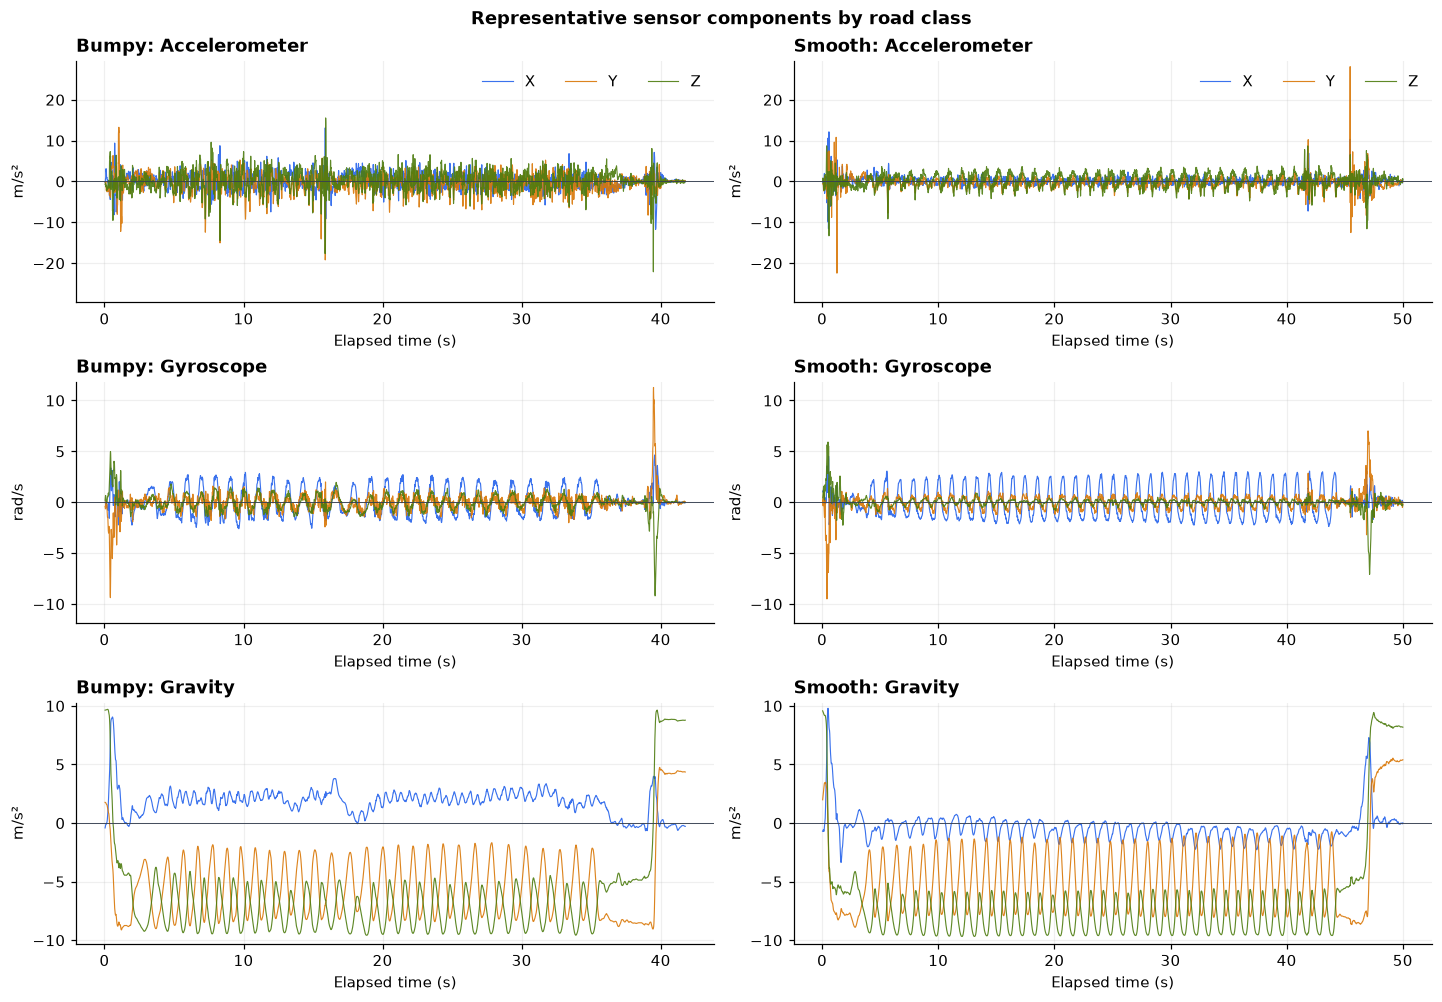

In [8]:
# load the same three sensors for a smooth comparison recording
smooth_streams = {
    sensor: pd.read_csv(SMOOTH_EXAMPLE_DIR / f"{sensor}.csv", float_precision="round_trip")
    for sensor in SENSORS
}
representative_streams = {"Bumpy": example_streams, "Smooth": smooth_streams}
axis_colors = {"x": "#2563EB", "y": "#D97706", "z": "#4D7C0F"}

# use one vertical range per sensor across both road classes
sensor_limits = {
    sensor: max(
        np.abs(streams[sensor][AXES].to_numpy()).max()
        for streams in representative_streams.values()
    )
    for sensor in SENSORS
}

fig, axes = plt.subplots(3, 2, figsize=(13, 9), layout="constrained")
for row, sensor in enumerate(SENSORS):
    bound = sensor_limits[sensor] * 1.05
    for column, (surface, streams) in enumerate(representative_streams.items()):
        ax = axes[row, column]
        data = streams[sensor]
        for component, color in axis_colors.items():
            ax.plot(
                data["seconds_elapsed"], data[component],
                label=component.upper(), color=color, linewidth=0.75, alpha=0.9,
            )
        ax.axhline(0, color="#374151", linewidth=0.6)
        ax.set_ylim(-bound, bound)
        ax.set_title(f"{surface}: {sensor}", loc="left", fontweight="bold")
        ax.set_ylabel(UNITS[sensor])
        ax.set_xlabel("Elapsed time (s)")
        ax.grid(alpha=0.2)
        if row == 0:
            ax.legend(loc="upper right", ncol=3, frameon=False)

fig.suptitle("Representative sensor components by road class", fontweight="bold")
plt.show()


The bumpy example has more sustained acceleration variation than the smooth example. Both gyroscope signals contain regular oscillation and short peaks; their ranges look similar in these two recordings. Gravity components change with phone orientation and pedalling motion, while gravity magnitude remains almost constant.

### Inspect acceleration magnitude

Magnitude combines the three acceleration axes as `sqrt(x² + y² + z²)`. It gives one measure of total acceleration without selecting a device axis. The September 8 lecture describes this type of feature combination. This plot is exploratory; it does not add magnitude to the exported data or select it as a model feature.

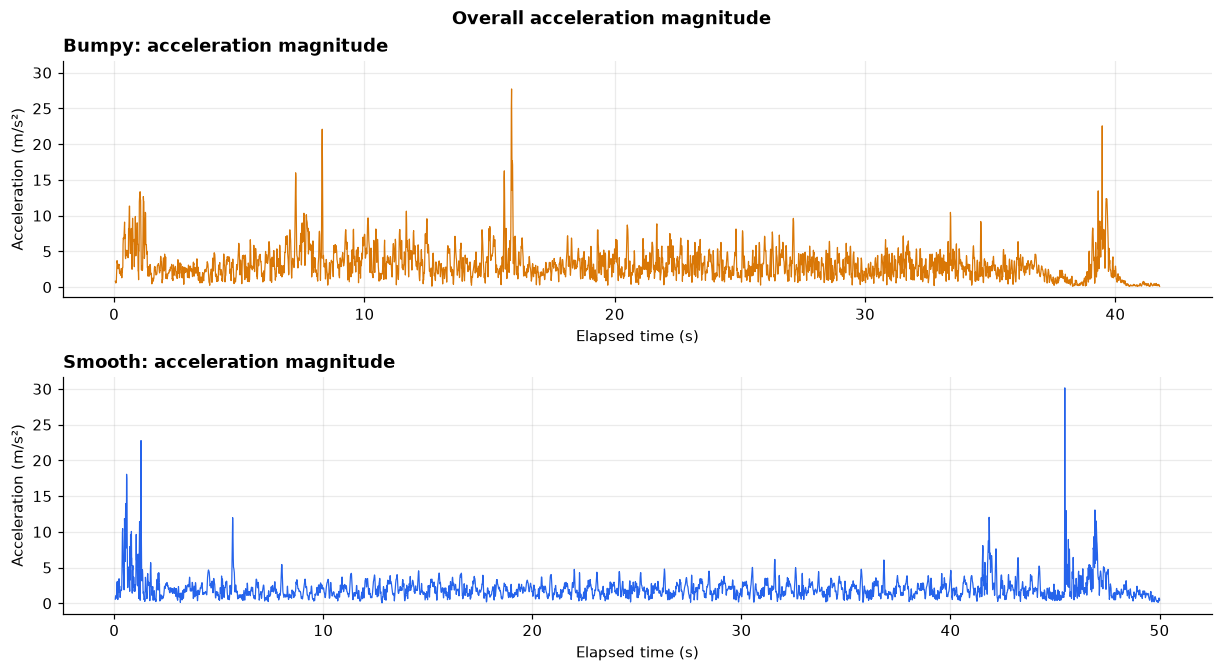

In [9]:
surface_colors = {"Bumpy": "#D97706", "Smooth": "#2563EB"}

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharey=True, layout="constrained")
for ax, (surface, streams) in zip(axes, representative_streams.items()):
    accelerometer = streams["Accelerometer"]
    # calculate magnitude without adding a derived column to the raw frame
    acceleration_magnitude = np.sqrt((accelerometer[AXES] ** 2).sum(axis=1))
    ax.plot(
        accelerometer["seconds_elapsed"], acceleration_magnitude,
        color=surface_colors[surface], linewidth=0.8,
    )
    ax.set_title(f"{surface}: acceleration magnitude", loc="left", fontweight="bold")
    ax.set_ylabel("Acceleration (m/s²)")
    ax.set_xlabel("Elapsed time (s)")
    ax.grid(alpha=0.25)

fig.suptitle("Overall acceleration magnitude", fontweight="bold")
plt.show()


The bumpy example has more sustained variation in acceleration magnitude. The smooth example stays closer to its baseline for most of the recording but contains a larger isolated peak. Maximum acceleration alone is therefore unlikely to separate the road classes. Dataset-wide analysis is needed before choosing features or treating peaks as errors.

## 5. Dataset-wide EDA and outlier inspection

Each recording is summarised after the dataset structure has been confirmed. Magnitude, `sqrt(x² + y² + z²)`, combines the three axes for comparison. This removes axis choice from the summaries, although phone movement and placement can still affect the values. Each plotted point represents one recording. The summaries support inspection and do not form a model feature table.

mean     std     min      max
sensor        participant_id class                                  
Accelerometer P01            bumpy   3.1881  2.2048  0.0724  23.4326
                             smooth  2.4815  1.6171  0.0699  30.1418
              P02            bumpy   3.0150  2.1281  0.0989  32.6253
                             smooth  1.9248  1.5808  0.0545  28.0876
Gravity       P01            bumpy   9.8067  0.0000  9.8066   9.8067
                             smooth  9.8067  0.0000  9.8066   9.8067
              P02            bumpy   9.8067  0.0000  9.8066   9.8067
                             smooth  9.8067  0.0000  9.8066   9.8067
Gyroscope     P01            bumpy   1.5224  1.0253  0.0301   9.8816
                             smooth  1.6224  1.0768  0.0194   9.4939
              P02            bumpy   1.4946  0.9274  0.0262   8.4400
                             smooth  1.4766  0.9785  0.0258   9.6356

mean     std      max
sensor        class                          
Accelerometer bumpy   3.0150  2.1281  32.6253
              smooth  1.9248  1.5808  28.0876
Gyroscope     bumpy   1.4946  0.9274   8.4400
              smooth  1.4766  0.9785   9.6356

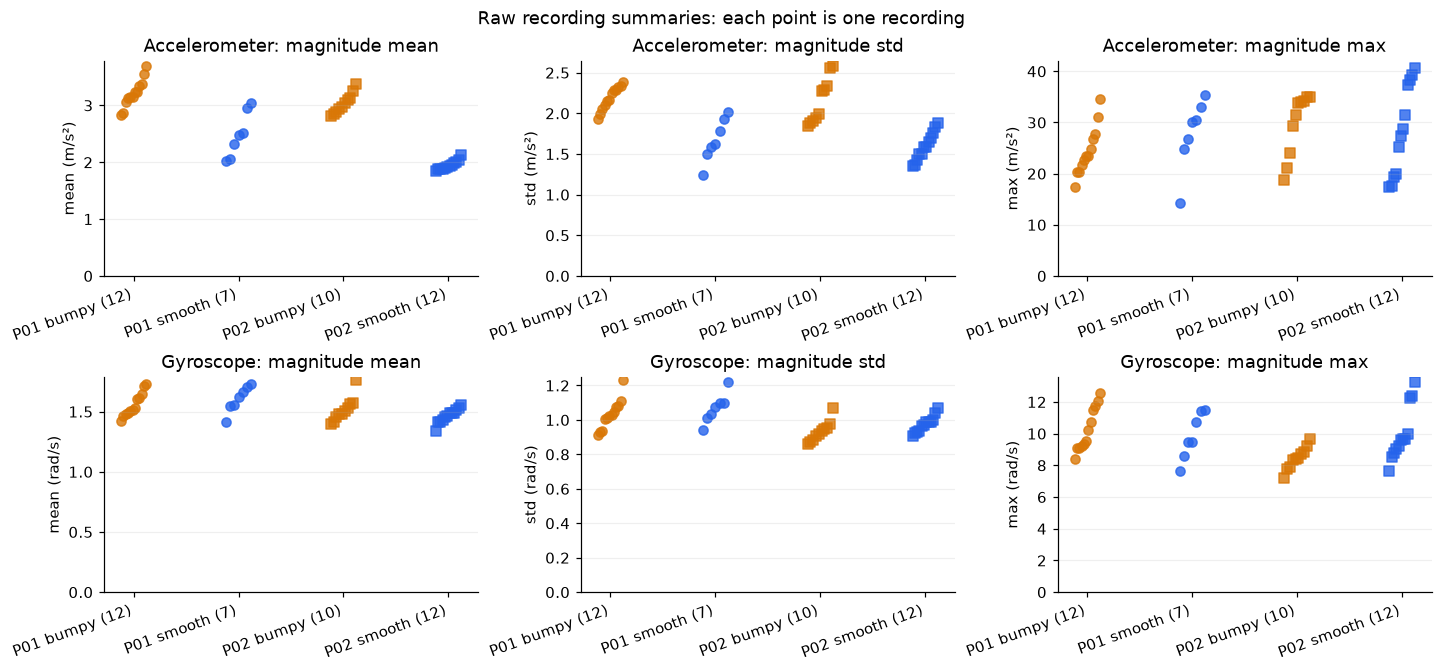

,recording_id,peak_m_s2,peak_elapsed_s,seconds_from_start,seconds_to_end,participant_id,class
20,R021,40.719,0.640,0.582,49.274,P02,smooth
16,R017,39.333,0.564,0.502,40.869,P02,smooth
19,R020,38.222,0.642,0.582,48.230,P02,smooth
18,R019,37.400,1.414,1.356,49.495,P02,smooth
30,R031,35.412,1.556,1.511,36.113,P01,smooth
31,R032,35.076,0.585,0.502,44.789,P02,bumpy
35,R036,34.962,32.129,32.067,22.459,P02,bumpy
7,R008,34.545,1.333,1.251,31.053,P01,bumpy


In [10]:
def magnitude(data):
    return np.sqrt((data[AXES] ** 2).sum(axis=1))

# summarize each axis and magnitude at recording level
signal_rows = []
for (rid, sensor), data in raw_streams.items():
    for component in [*AXES, "magnitude"]:
        values = magnitude(data) if component == "magnitude" else data[component]
        signal_rows.append({"recording_id": rid, "sensor": sensor, "component": component,
                            "mean": values.mean(), "std": values.std(), "min": values.min(),
                            "median": values.median(), "max": values.max()})
signal_summary = pd.DataFrame(signal_rows).merge(
    recording_index[["recording_id", "participant_id", "class"]],
    on="recording_id", validate="many_to_one")
display(signal_summary.query("component == 'magnitude'").groupby(
    ["sensor", "participant_id", "class"])[["mean", "std", "min", "max"]].median().round(4))

# compare Brian's two road classes with participant and device held constant
p02_comparison = (
    signal_summary.query(
        "component == 'magnitude' and participant_id == 'P02' "
        "and sensor in ['Accelerometer', 'Gyroscope']"
    )
    .groupby(["sensor", "class"])[["mean", "std", "max"]]
    .median()
    .round(4)
)
display(p02_comparison)

# derive plot groups and labels from combinations present in the data
group_counts = recording_index.groupby(["participant_id", "class"]).size()
GROUPS = [
    (participant, label)
    for participant in sorted(recording_index["participant_id"].unique())
    for label in ["bumpy", "smooth"]
    if (participant, label) in group_counts.index
]
GROUP_LABELS = [
    f"{participant} {label} ({group_counts.loc[(participant, label)]})"
    for participant, label in GROUPS
]

fig, axes = plt.subplots(2, 3, figsize=(13, 6), layout="constrained")
for row, sensor in enumerate(["Accelerometer", "Gyroscope"]):
    for col, statistic in enumerate(["mean", "std", "max"]):
        ax = axes[row, col]
        for position, (person, label) in enumerate(GROUPS):
            values = signal_summary.query(
                "sensor == @sensor and component == 'magnitude' and participant_id == @person and `class` == @label"
            )[statistic].sort_values().to_numpy()
            offsets = np.linspace(-0.12, 0.12, len(values))
            ax.scatter(position + offsets, values, color=surface_colors[label.title()],
                       marker="o" if person == "P01" else "s", alpha=.8)
        ax.set_xticks(range(len(GROUPS)), GROUP_LABELS, rotation=20, ha="right")
        ax.set_ylabel(f"{statistic} ({UNITS[sensor]})")
        ax.set_title(f"{sensor}: magnitude {statistic}")
        ax.set_ylim(bottom=0)
        ax.grid(axis="y", alpha=.2)
fig.suptitle("Raw recording summaries: each point is one recording")
plt.show()

# record where each file's largest acceleration occurs
peak_rows = []
for (rid, sensor), data in raw_streams.items():
    if sensor != "Accelerometer":
        continue
    values = magnitude(data)
    peak_index = values.idxmax()
    peak_rows.append({"recording_id": rid, "peak_m_s2": values.loc[peak_index],
                      "peak_elapsed_s": data.loc[peak_index, "seconds_elapsed"],
                      "seconds_from_start": data.loc[peak_index, "seconds_elapsed"] - data.seconds_elapsed.iloc[0],
                      "seconds_to_end": data.seconds_elapsed.iloc[-1] - data.loc[peak_index, "seconds_elapsed"]})
peak_summary = pd.DataFrame(peak_rows).merge(
    recording_index[["recording_id", "participant_id", "class"]], on="recording_id", validate="one_to_one")
display(peak_summary.nlargest(8, "peak_m_s2").round(3))

The largest acceleration peak is 40.72 m/s² in smooth recording R021 at 0.64 s. Several other large smooth peaks occur near recording starts. A large value can reflect phone handling, a road event, or both, so the peak alone does not justify deleting a sample.

Within P02, the median acceleration-magnitude standard deviation is 2.128 m/s² for bumpy rides and 1.581 m/s² for smooth rides. The corresponding mean magnitudes are 3.015 and 1.925 m/s². The gyroscope summaries overlap more: its median magnitude standard deviation is 0.927 rad/s for bumpy rides and 0.979 rad/s for smooth rides. The acceleration difference is consistent with rougher motion, although the ten bumpy rides also share a route and collection session.

Gravity magnitude stays near 9.80665 m/s² even when its individual axes change with phone orientation. The next section checks whether the recording edges need to be removed.

## 6. Investigate possible start/end contamination

The collection protocol includes handling the phone before cycling and after stopping. The raw road label applies to the recording, not necessarily to every individual sample. This check therefore compares fixed **five-second start and end segments** with an equally long segment centered in the recording. Five seconds is a transparent review width: it is long enough to describe sustained movement at the observed ~100 Hz sampling rate, but it is not an inferred cycling boundary.

For accelerometer and gyroscope, the diagnostic uses the standard deviation of vector magnitude within each segment. For gravity, vector magnitude is nearly constant by construction, so it uses the 95th percentile of the rate of change of the three gravity components; this reveals orientation movement without treating a changing gravity direction as a change in gravity strength. These are EDA diagnostics, not features for the later model.

An edge/centre ratio above one means that one edge is more variable than the middle reference segment. It is evidence consistent with setup/stopping activity, not ground-truth proof: a genuine bump, turn, or stop can occur in the middle, while genuine cycling can occur at the edge.

In [11]:
EDGE_SECONDS = 5.0

if quality["duration_s"].min() <= 3 * EDGE_SECONDS:
    raise ValueError("A recording is too short for non-overlapping start, middle and end checks.")


def segment_masks(elapsed_seconds, edge_seconds=EDGE_SECONDS):
    elapsed = elapsed_seconds - elapsed_seconds.iloc[0]
    duration = elapsed.iloc[-1]
    middle_start = duration / 2 - edge_seconds / 2
    middle_end = duration / 2 + edge_seconds / 2
    return {
        "start": elapsed <= edge_seconds,
        "middle": elapsed.between(middle_start, middle_end),
        "end": elapsed >= duration - edge_seconds,
    }


boundary_rows = []
for (recording_id, sensor), data in raw_streams.items():
    elapsed = data["seconds_elapsed"] - data["seconds_elapsed"].iloc[0]
    masks = segment_masks(data["seconds_elapsed"])
    vector_magnitude = magnitude(data)

    # Gravity's magnitude is intentionally near-constant; component change is the useful diagnostic.
    component_change_rate = (
        np.sqrt((data[AXES].diff() ** 2).sum(axis=1)) / elapsed.diff()
    ).replace([np.inf, -np.inf], np.nan)

    for segment, mask in masks.items():
        values = vector_magnitude.loc[mask]
        change_rates = component_change_rate.loc[mask].dropna()
        boundary_rows.append({
            "recording_id": recording_id,
            "sensor": sensor,
            "segment": segment,
            "n_samples": len(values),
            "magnitude_sd": values.std(),
            "magnitude_p95": values.quantile(0.95),
            "component_change_rate_p95": change_rates.quantile(0.95),
        })

boundary_summary = pd.DataFrame(boundary_rows).merge(
    recording_index[["recording_id", "participant_id", "class", "source_recording"]],
    on="recording_id", validate="many_to_one",
)

boundary_metric = np.where(
    boundary_summary["sensor"].eq("Gravity"),
    boundary_summary["component_change_rate_p95"],
    boundary_summary["magnitude_sd"],
)
boundary_summary["diagnostic_value"] = boundary_metric
boundary_summary["diagnostic_unit"] = np.where(
    boundary_summary["sensor"].eq("Gravity"), "m/s³", "sensor unit",
)

boundary_scores = (
    boundary_summary.pivot(
        index=["recording_id", "participant_id", "class", "source_recording", "sensor"],
        columns="segment", values="diagnostic_value",
    )
    .reset_index()
)
boundary_scores["edge_max"] = boundary_scores[["start", "end"]].max(axis=1)
boundary_scores["edge_to_middle_ratio"] = np.where(
    boundary_scores["middle"] > 0,
    boundary_scores["edge_max"] / boundary_scores["middle"],
    np.nan,
)
boundary_scores["higher_edge"] = np.where(
    boundary_scores["start"] >= boundary_scores["end"], "start", "end"
)

display(boundary_summary.groupby(["sensor", "segment"])["diagnostic_value"].median().unstack().round(3))
display(
    boundary_scores.query("sensor != 'Gravity'")
    .sort_values("edge_to_middle_ratio", ascending=False)
    [["recording_id", "participant_id", "class", "sensor", "higher_edge",
      "start", "middle", "end", "edge_to_middle_ratio"]]
    .head(12).round(3)
)


segment,end,middle,start
sensor,,,
Accelerometer,2.209,1.489,2.902
Gravity,44.220,25.566,41.578
Gyroscope,1.683,0.704,1.501


segment,recording_id,participant_id,class,sensor,higher_edge,start,middle,end,edge_to_middle_ratio
60,R021,P02,smooth,Accelerometer,start,3.896,0.853,2.258,4.570
39,R014,P02,smooth,Accelerometer,start,3.067,0.733,2.401,4.184
54,R019,P02,smooth,Accelerometer,start,3.769,0.903,1.782,4.174
36,R013,P02,smooth,Accelerometer,start,3.204,0.770,0.873,4.159
48,R017,P02,smooth,Accelerometer,start,3.940,1.011,2.450,3.895
42,R015,P02,smooth,Accelerometer,start,3.362,0.872,2.546,3.854
57,R020,P02,smooth,Accelerometer,start,3.966,1.048,2.789,3.783
2,R001,P01,bumpy,Gyroscope,end,1.510,0.614,2.239,3.650
8,R003,P01,bumpy,Gyroscope,end,1.599,0.646,2.181,3.375
72,R025,P01,smooth,Accelerometer,start,2.618,0.832,2.404,3.145


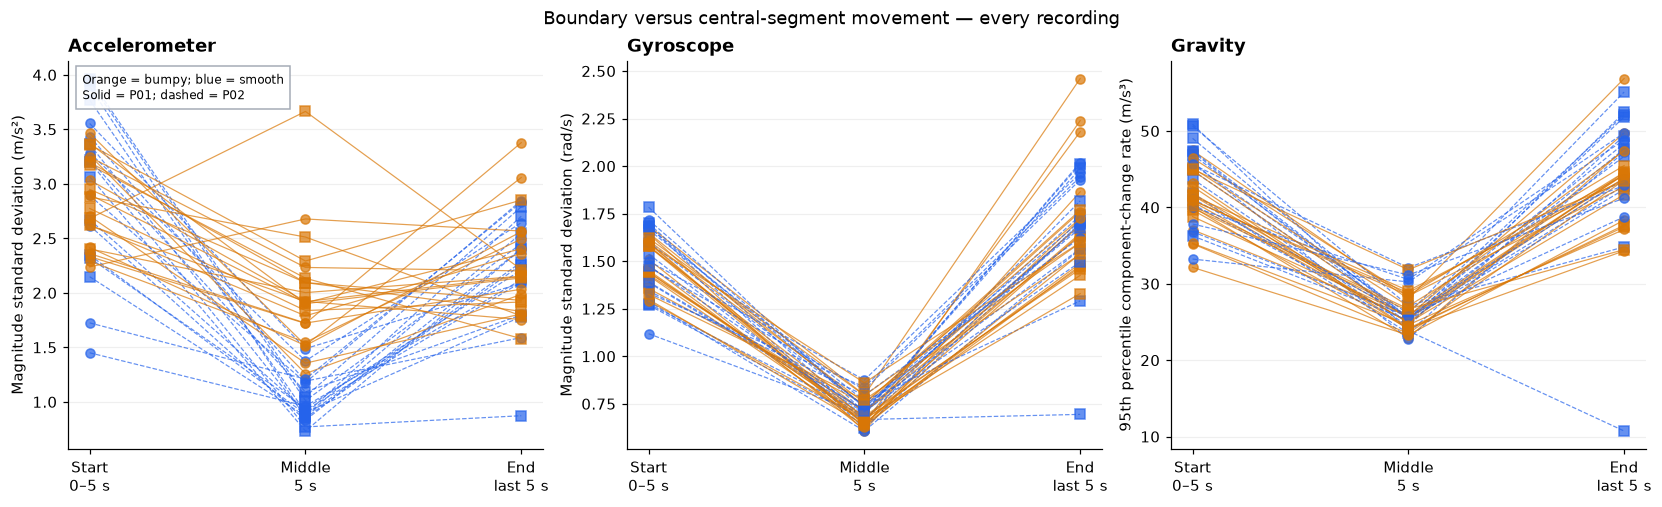

Detailed review recordings: R021, R014, R019


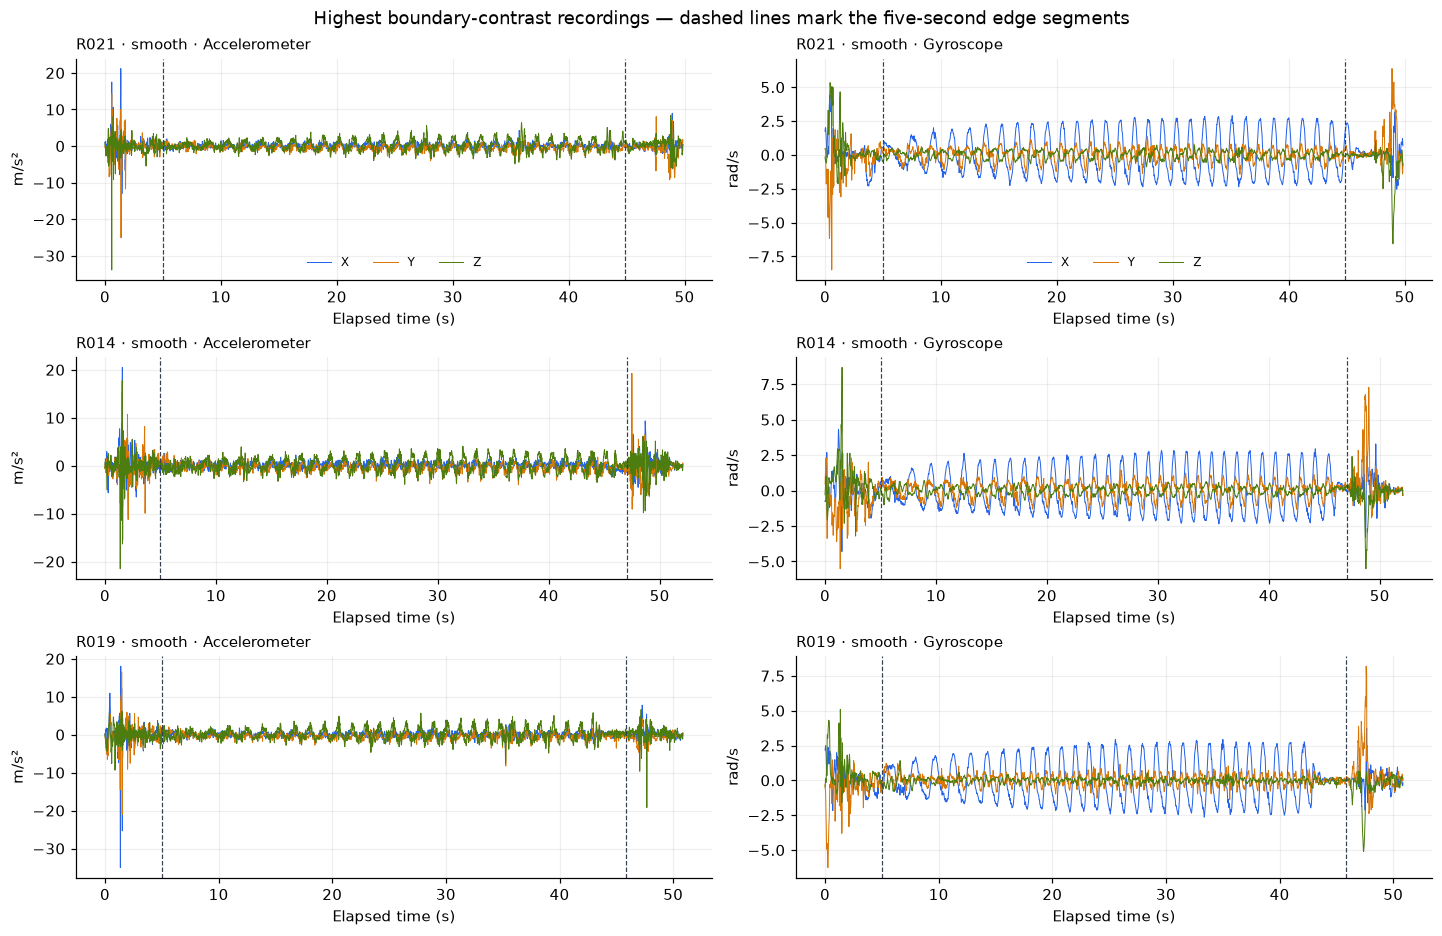

In [12]:
# Each line is one recording; the same segment order is used for every panel.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), layout="constrained")
for ax, sensor in zip(axes, SENSORS):
    plot_data = boundary_scores.query("sensor == @sensor").copy()
    plot_data = plot_data.sort_values("edge_to_middle_ratio", ascending=False)
    for _, row in plot_data.iterrows():
        style = "-" if row["class"] == "bumpy" else "--"
        color = surface_colors[row["class"].title()]
        marker = "o" if row["participant_id"] == "P01" else "s"
        ax.plot([0, 1, 2], row[["start", "middle", "end"]], style,
                color=color, marker=marker, linewidth=0.8, alpha=0.7)
    ax.set_xticks([0, 1, 2], ["Start\n0–5 s", "Middle\n5 s", "End\nlast 5 s"])
    ax.set_title(sensor, loc="left", fontweight="bold")
    ax.grid(axis="y", alpha=0.2)
    if sensor == "Gravity":
        ax.set_ylabel("95th percentile component-change rate (m/s³)")
    else:
        ax.set_ylabel(f"Magnitude standard deviation ({UNITS[sensor]})")
    if sensor == "Accelerometer":
        ax.text(0.03, 0.97, "Orange = bumpy; blue = smooth\nSolid = P01; dashed = P02",
                transform=ax.transAxes, va="top", fontsize=8,
                bbox={"facecolor": "white", "edgecolor": "#9CA3AF", "alpha": 0.9})

fig.suptitle("Boundary versus central-segment movement — every recording")
plt.show()

# Inspect the three recordings with the largest accelerometer boundary/centre contrast.
REVIEW_RECORDING_IDS = (
    boundary_scores.query("sensor == 'Accelerometer'")
    .nlargest(3, "edge_to_middle_ratio")["recording_id"].tolist()
)
print("Detailed review recordings:", ", ".join(REVIEW_RECORDING_IDS))

fig, axes = plt.subplots(len(REVIEW_RECORDING_IDS), 2, figsize=(13, 2.8 * len(REVIEW_RECORDING_IDS)),
                         squeeze=False, layout="constrained")
for row, recording_id in enumerate(REVIEW_RECORDING_IDS):
    record = recording_index.set_index("recording_id").loc[recording_id]
    for col, sensor in enumerate(["Accelerometer", "Gyroscope"]):
        ax = axes[row, col]
        data = raw_streams[(recording_id, sensor)]
        elapsed = data["seconds_elapsed"] - data["seconds_elapsed"].iloc[0]
        for axis, color in axis_colors.items():
            ax.plot(elapsed, data[axis], color=color, linewidth=0.65, label=axis.upper())
        for boundary in (EDGE_SECONDS, elapsed.iloc[-1] - EDGE_SECONDS):
            ax.axvline(boundary, color="#374151", linestyle="--", linewidth=0.8)
        ax.set_title(f"{recording_id} · {record['class']} · {sensor}", loc="left", fontsize=10)
        ax.set_xlabel("Elapsed time (s)")
        ax.set_ylabel(UNITS[sensor])
        ax.grid(alpha=0.2)
        if row == 0:
            ax.legend(ncol=3, frameon=False, fontsize=8)
fig.suptitle("Highest boundary-contrast recordings — dashed lines mark the five-second edge segments")
plt.show()


### Boundary check result

Movement is usually stronger at the recording edges than in the five-second middle segment. The median accelerometer magnitude standard deviation is 2.902 m/s² at the start, 1.489 m/s² in the middle, and 2.209 m/s² at the end. For the gyroscope, the corresponding values are 1.501, 0.704, and 1.683 rad/s. The gravity-direction diagnostic also has higher median values at the edges.

R021, R014, and R019 have the largest accelerometer boundary-to-middle ratios, with strong movement in their first five seconds. Several P01 bumpy recordings have stronger gyroscope movement at the end. This pattern occurs in both road labels and is consistent with putting the phone away or taking it out. The sensor data cannot identify exactly which samples are handling, stopping, or normal cycling motion.

The annotation files do not contain cycling start and stop times, so no reproducible cropping rule follows from this diagnostic. The complete recordings remain in the export. Any later rule for excluding edge windows should be decided before modelling, applied to every recording, and documented.

## 7. Preprocessing decision: preserve complete recordings

The beginning or end of a recording may contain phone handling. The annotation files do not identify when cycling starts or stops, and the available measurements do not provide a reproducible rule that separates handling from genuine road motion.

Every row in all three sensor streams is preserved. Choosing cutoffs by eye would add a decision that cannot be reproduced and could remove useful signal. Possible handling at the recording edges remains a limitation for later windowing and modelling.

In [13]:
# copy complete streams so the source dataframes stay untouched
prepared_streams = {key: data.copy() for key, data in raw_streams.items()}

# record the sample counts and verify that preparation changes nothing
preparation_rows = []
for record in recording_index.itertuples(index=False):
    for sensor in SENSORS:
        key = (record.recording_id, sensor)
        raw = raw_streams[key]
        prepared = prepared_streams[key]
        pd.testing.assert_frame_equal(raw, prepared)
        preparation_rows.append({
            "recording_id": record.recording_id,
            "participant_id": record.participant_id,
            "class": recording_index.loc[recording_index.recording_id.eq(record.recording_id), "class"].iat[0],
            "sensor": sensor,
            "input_samples": len(raw),
            "output_samples": len(prepared),
            "sample_count_change": len(prepared) - len(raw),
            "action": "complete recording preserved",
        })

preprocessing_log = pd.DataFrame(preparation_rows)
display(preprocessing_log.groupby("sensor", sort=False).agg(
    streams=("recording_id", "size"),
    input_samples=("input_samples", "sum"),
    output_samples=("output_samples", "sum"),
    sample_count_change=("sample_count_change", "sum"),
))
print(f"Prepared {len(prepared_streams)} complete sensor streams without changing their samples.")

,streams,input_samples,output_samples,sample_count_change
sensor,,,,
Accelerometer,41,192366,192366,0
Gyroscope,41,192367,192367,0
Gravity,41,192367,192367,0


Prepared 123 complete sensor streams without changing their samples.


Every recorded sample remains available. Larger movements near the recording edges remain in the data because the recordings contain no independent start/stop labels that would justify excluding them. Later modelling should account for this through a documented window-selection rule fitted only on the training data.

In [14]:
# repeat the structural checks on the prepared copies
validated_quality = pd.DataFrame([
    {"recording_id": recording_id, "sensor": sensor, **assess_stream(data)}
    for (recording_id, sensor), data in prepared_streams.items()
]).merge(
    recording_index[["recording_id", "participant_id", "class"]],
    on="recording_id",
    validate="many_to_one",
)

display(validated_quality.groupby("sensor", sort=False)[ISSUE_COLUMNS].sum())

# compare full sample totals before and after preparation
raw_totals = quality.groupby("sensor", sort=False).agg(
    recordings=("recording_id", "size"),
    input_samples=("n_samples", "sum"),
)
prepared_totals = validated_quality.groupby("sensor", sort=False).agg(
    output_samples=("n_samples", "sum"),
)
sample_totals = raw_totals.join(prepared_totals)
sample_totals["sample_count_change"] = (
    sample_totals["output_samples"] - sample_totals["input_samples"]
)
display(sample_totals)

if validated_quality[ISSUE_COLUMNS].to_numpy().sum() != 0:
    raise ValueError("A prepared stream failed the structural checks.")
if preprocessing_log["sample_count_change"].ne(0).any():
    raise ValueError("Preparation changed a stream's sample count.")

,missing_values,infinite_values,duplicate_rows,duplicate_timestamps,non_positive_intervals,non_positive_epoch_intervals
sensor,,,,,,
Accelerometer,0,0,0,0,0,0
Gyroscope,0,0,0,0,0,0
Gravity,0,0,0,0,0,0


,recordings,input_samples,output_samples,sample_count_change
sensor,,,,
Accelerometer,41,192366,192366,0
Gyroscope,41,192367,192367,0
Gravity,41,192367,192367,0


### Preparation result

All 41 recordings and all three sensor types remain complete. The export contains **192,366 accelerometer samples**, **192,367 gyroscope samples** and **192,367 gravity samples**. Values, timestamps, and sample counts remain unchanged, and the structural checks still pass after preparation.

Possible phone handling at the start and end of a ride is documented as a limitation. The signals remain unscaled and unfiltered.

## 8. Save the validated recordings

Each sensor stream is written to its own CSV with a stable recording ID. The export also includes the recording manifest, the preprocessing log and quality summaries for both the source and validated copies.

In [15]:
# save complete sensor streams with stable names
PROCESSED_DIR = PROJECT_ROOT / "data" / "recordings" / "processed" / "current"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
manifest_rows = []
for record in recording_index.itertuples(index=False):
    rid = record.recording_id
    for sensor in SENSORS:
        data = prepared_streams[(rid, sensor)]
        relative_path = Path(record.participant_id) / rid / f"{sensor}.csv"
        output_path = PROCESSED_DIR / relative_path
        output_path.parent.mkdir(parents=True, exist_ok=True)
        data.to_csv(output_path, index=False)

        # confirm that saving and loading preserve every value and timestamp
        saved = pd.read_csv(output_path, float_precision="round_trip")
        pd.testing.assert_frame_equal(
            data.reset_index(drop=True), saved, check_dtype=False, rtol=1e-12, atol=1e-12
        )
        manifest_rows.append({
            "recording_id": rid,
            "participant_id": record.participant_id,
            "class": recording_index.loc[
                recording_index.recording_id.eq(rid), "class"
            ].iat[0],
            "source_recording": record.source_recording,
            "source_folder": record.source_folder,
            "device": record.device,
            "sensor": sensor,
            "relative_path": relative_path.as_posix(),
            "n_samples": len(data),
            "units_xyz": UNITS[sensor],
        })

manifest = pd.DataFrame(manifest_rows)
manifest.to_csv(PROCESSED_DIR / "manifest.csv", index=False)
preprocessing_log.to_csv(PROCESSED_DIR / "preprocessing_log.csv", index=False)
quality.to_csv(PROCESSED_DIR / "quality_raw.csv", index=False)
validated_quality.to_csv(PROCESSED_DIR / "quality_validated.csv", index=False)

# require processed ride files to agree exactly with the manifest
expected_sensor_files = set(manifest["relative_path"])
actual_sensor_files = {
    path.relative_to(PROCESSED_DIR).as_posix()
    for path in PROCESSED_DIR.glob("P*/R*/*.csv")
}
missing_sensor_files = sorted(expected_sensor_files - actual_sensor_files)
stale_sensor_files = sorted(actual_sensor_files - expected_sensor_files)
expected_ride_dirs = {str(Path(path).parent) for path in expected_sensor_files}
actual_ride_dirs = {
    path.relative_to(PROCESSED_DIR).as_posix()
    for path in PROCESSED_DIR.glob("P*/R*") if path.is_dir()
}
missing_ride_dirs = sorted(expected_ride_dirs - actual_ride_dirs)
stale_ride_dirs = sorted(actual_ride_dirs - expected_ride_dirs)
if missing_sensor_files or stale_sensor_files or missing_ride_dirs or stale_ride_dirs:
    raise ValueError(
        "Processed outputs do not match the manifest. "
        f"Missing files: {missing_sensor_files}; stale files: {stale_sensor_files}; "
        f"missing ride folders: {missing_ride_dirs}; stale ride folders: {stale_ride_dirs}."
    )

print(f"Saved {manifest.recording_id.nunique()} complete recordings to {PROCESSED_DIR}")
display(manifest.head())

Saved 41 complete recordings to /Users/larsheijnen/Developer/university/DataAnalysis-LearningMethods/Assignment 1/data/recordings/processed/current


,recording_id,participant_id,class,source_recording,source_folder,device,sensor,relative_path,n_samples,units_xyz
0,R001,P01,bumpy,cb_2_bumpy_lars,bumpy/lars/cb_2_bumpy_lars,iPhone 17 Pro,Accelerometer,P01/R001/Accelerometer.csv,4170,m/s²
1,R001,P01,bumpy,cb_2_bumpy_lars,bumpy/lars/cb_2_bumpy_lars,iPhone 17 Pro,Gyroscope,P01/R001/Gyroscope.csv,4170,rad/s
2,R001,P01,bumpy,cb_2_bumpy_lars,bumpy/lars/cb_2_bumpy_lars,iPhone 17 Pro,Gravity,P01/R001/Gravity.csv,4170,m/s²
3,R002,P01,bumpy,cb_3_bumpy_lars,bumpy/lars/cb_3_bumpy_lars,iPhone 17 Pro,Accelerometer,P01/R002/Accelerometer.csv,4268,m/s²
4,R002,P01,bumpy,cb_3_bumpy_lars,bumpy/lars/cb_3_bumpy_lars,iPhone 17 Pro,Gyroscope,P01/R002/Gyroscope.csv,4268,rad/s


### Output handoff

- `manifest.csv` maps each stable recording ID to its participant, class, original raw folder, device, and sensor file.
- `P##/R###/Accelerometer.csv`, `Gyroscope.csv`, and `Gravity.csv` contain the complete sensor streams with `time`, `seconds_elapsed`, `z`, `y`, and `x`.
- `preprocessing_log.csv` confirms the input and output sample counts for every stream.
- `quality_raw.csv` and `quality_validated.csv` contain the structural checks before and after preparation.

The tracked `recording_registry.csv` outside the processed folder preserves recording IDs when raw recordings are added. Each saved sensor file has been read back and compared with its in-memory source. The notebook can rebuild the export from the raw recordings and registry.

## Optional full-recording inspection

The main analysis uses representative recordings and dataset-wide summaries. Setting `SHOW_ALL_RECORDINGS = True` runs the next cell after Sections 1 to 6 and plots four recordings per page. The cell is off by default so the notebook remains readable.

In [16]:
SHOW_ALL_RECORDINGS = False

if SHOW_ALL_RECORDINGS:
    axis_limits = {
        sensor: max(raw_streams[(rid, sensor)][AXES].abs().to_numpy().max()
                    for rid in recording_index.recording_id) * 1.05
        for sensor in SENSORS
    }
    sensor_labels = {
        "Accelerometer": "Acceleration (m/s²)",
        "Gyroscope": "Angular velocity (rad/s)",
        "Gravity": "Gravity (m/s²)",
    }
    for page_start in range(0, len(recording_index), 4):
        page = recording_index.iloc[page_start:page_start + 4]
        fig, axes = plt.subplots(len(page) * 3, 1, figsize=(15, 2.1 * len(page) * 3), squeeze=False)
        for record_offset, record in enumerate(page.itertuples(index=False)):
            for sensor_offset, sensor in enumerate(SENSORS):
                ax = axes[record_offset * 3 + sensor_offset, 0]
                data = raw_streams[(record.recording_id, sensor)]
                for axis in AXES:
                    ax.plot(data["seconds_elapsed"], data[axis],
                            color=axis_colors[axis], linewidth=0.65, label=axis)
                ax.set_ylim(-axis_limits[sensor], axis_limits[sensor])
                ax.set_ylabel(sensor_labels[sensor])
                ax.set_title(f"{record.recording_id}: {recording_index.loc[recording_index.recording_id.eq(record.recording_id), 'class'].iat[0]} — {sensor}", loc="left")
                ax.grid(alpha=0.2)
                if record_offset == 0 and sensor_offset == 0:
                    ax.legend(ncol=3, loc="upper right")
        axes[-1, 0].set_xlabel("Seconds elapsed")
        fig.suptitle(f"Complete recording inspection {page_start // 4 + 1}")
        fig.tight_layout()
        plt.show()
else:
    print("Set SHOW_ALL_RECORDINGS = True to plot every complete recording.")

Set SHOW_ALL_RECORDINGS = True to plot every complete recording.
